# Tema 4 - Algoritmos de Regresión
**Autor:** Omar Recalde  
**Repositorio:** [Machine Learning Portfolio](https://github.com/OmaRecalde/machinelearning2026)  
**Asignatura:** Aprendizaje Supervisado | Instituto Superior Tecnológico Quito (ITQ)  

---
## 1. Regresión Lineal Múltiple (Ordinary Least Squares - OLS)

La Regresión Lineal Múltiple modela la relación entre varios atributos $X$ y una variable objetivo continua $\hat{y}$ mediante una combinación lineal:
$$ \hat{y} = w_0 + w_1 x_1 + \dots + w_p x_p $$

En esta sección implementamos el flujo completo de evaluación de OLS usando validación cruzada y estandarización de atributos.

In [2]:
!pip install scikit-learn matplotlib numpy pandas

In [4]:
import numpy as np
from math import sqrt
from pprint import pprint
import matplotlib.pyplot as plt

from sklearn import datasets, linear_model, metrics, preprocessing
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import make_scorer

# 1. Carga de dataset (California Housing)
housing = datasets.fetch_california_housing()
X = housing.data
y = housing.target

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# 2. Definición de Métricas Personalizadas de Evaluación
metricas = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': make_scorer(lambda y_true, y_pred: sqrt(metrics.mean_squared_error(y_true, y_pred)), greater_is_better=False),
    'MAPE': make_scorer(lambda y_true, y_pred: np.mean(np.abs((y_true - y_pred) / y_true)) * 100, greater_is_better=False),
    'R2': 'r2'
}

# 3. Partición de datos externa (Hold-Out 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Muestras de Entrenamiento: {X_train.shape[0]}, Muestras de Test: {X_test.shape[0]}")

Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)
Muestras de Entrenamiento: 16512, Muestras de Test: 4128


In [5]:
# 4. Estandarización de datos de entrenamiento
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_train)
X_train_stdr = stdr_trained.transform(X_train)

# 5. Algoritmo de Aprendizaje (OLS)
reg = linear_model.LinearRegression(fit_intercept=True)

# 5.1 Validación Cruzada Interna (5-Fold CV)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cross_val_results = cross_validate(reg, X_train_stdr, y_train, cv=kfold, scoring=metricas)

print("--- RESULTADOS DE VALIDACIÓN CRUZADA ---")
print(f"R2 Promedio: {cross_val_results['test_R2'].mean():.4f}")
print(f"MAE Promedio: {-cross_val_results['test_MAE'].mean():.4f}")

# 5.2 Entrenamiento definitivo con todo el conjunto de Train
model = reg.fit(X_train_stdr, y_train)

# Obtención de coeficientes (w) y término independiente (w0)
print("\n--- COEFICIENTES DEL MODELO ---")
print(f"Término independiente (w0): {model.intercept_:.4f}")
for feature, coef in zip(housing.feature_names, model.coef_):
    print(f"Coeficiente {feature} (w): {coef:.4f}")

--- RESULTADOS DE VALIDACIÓN CRUZADA ---
R2 Promedio: 0.6115
MAE Promedio: 0.5291

--- COEFICIENTES DEL MODELO ---
Término independiente (w0): 2.0719
Coeficiente MedInc (w): 0.8544
Coeficiente HouseAge (w): 0.1225
Coeficiente AveRooms (w): -0.2944
Coeficiente AveBedrms (w): 0.3393
Coeficiente Population (w): -0.0023
Coeficiente AveOccup (w): -0.0408
Coeficiente Latitude (w): -0.8969
Coeficiente Longitude (w): -0.8698


MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
MAPE: 31.9522%
R2:   0.5758


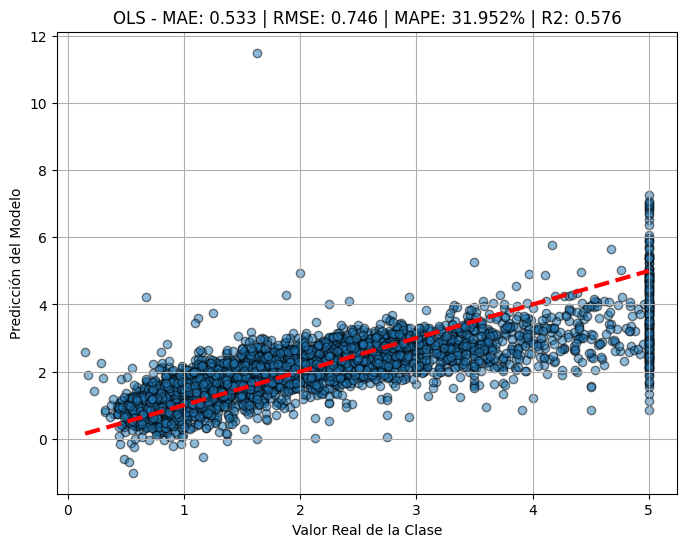

In [6]:
# 6. Transformación de datos de test
X_test_stdr = stdr_trained.transform(X_test)

# 7. Predicción
y_pred_test = model.predict(X_test_stdr)

# 8. Métricas en Test
MAE = metrics.mean_absolute_error(y_test, y_pred_test)
MSE = metrics.mean_squared_error(y_test, y_pred_test)
RMSE = np.sqrt(MSE)
MAPE = metrics.mean_absolute_percentage_error(y_test, y_pred_test) * 100
R2 = metrics.r2_score(y_test, y_pred_test)

print(f"MAE:  {MAE:.4f}")
print(f"MSE:  {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")
print(f"MAPE: {MAPE:.4f}%")
print(f"R2:   {R2:.4f}")

# 9. Gráfica de Realidad vs. Predicción
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, edgecolors=(0, 0, 0), alpha=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
ax.set_xlabel('Valor Real de la Clase')
ax.set_ylabel('Predicción del Modelo')
plt.title(f"OLS - MAE: {MAE:.3f} | RMSE: {RMSE:.3f} | MAPE: {MAPE:.3f}% | R2: {R2:.3f}")
plt.grid(True)
plt.show()

---
## 2. Regularización: Lasso (L1) y Ridge (L2)

Para evitar el sobreajuste y gestionar la multicolinealidad en modelos de regresión lineal, incorporamos penalizaciones a los coeficientes:
* **Lasso (L1):** Añade la suma de los valores absolutos de los coeficientes. Puede hacer coeficientes exactos a cero (selección de atributos).
* **Ridge (L2):** Añade la suma de los cuadrados de los coeficientes. Reduce la magnitud de los coeficientes sin anularlos del todo.

In [7]:
# Definición y entrenamiento de Lasso y Ridge
lasso = linear_model.Lasso(alpha=0.1, random_state=42)
ridge = linear_model.Ridge(alpha=1.0, random_state=42)

lasso.fit(X_train_stdr, y_train)
ridge.fit(X_train_stdr, y_train)

# Evaluaciones en Test
y_pred_lasso = lasso.predict(X_test_stdr)
y_pred_ridge = ridge.predict(X_test_stdr)

print("--- REGULARIZACIÓN LASSO ---")
print(f"R2: {metrics.r2_score(y_test, y_pred_lasso):.4f} | RMSE: {np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso)):.4f}")

print("\n--- REGULARIZACIÓN RIDGE ---")
print(f"R2: {metrics.r2_score(y_test, y_pred_ridge):.4f} | RMSE: {np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge)):.4f}")

--- REGULARIZACIÓN LASSO ---
R2: 0.4814 | RMSE: 0.8244

--- REGULARIZACIÓN RIDGE ---
R2: 0.5758 | RMSE: 0.7456


---
## 3. Algoritmo K-Nearest Neighbors (k-NN) para Regresión

k-NN asigna como predicción la media de los $k$ vecinos más cercanos evaluados mediante una función de distancia (e.g. Euclídea / Minkowski).
Es crítico **normalizar/estandarizar** las variables para evitar que atributos con escalas grandes dominen el cálculo de distancias.

R2 de k-NN (Estandarizado):    0.6783
R2 de k-NN (Sin Estandarizar): 0.1554


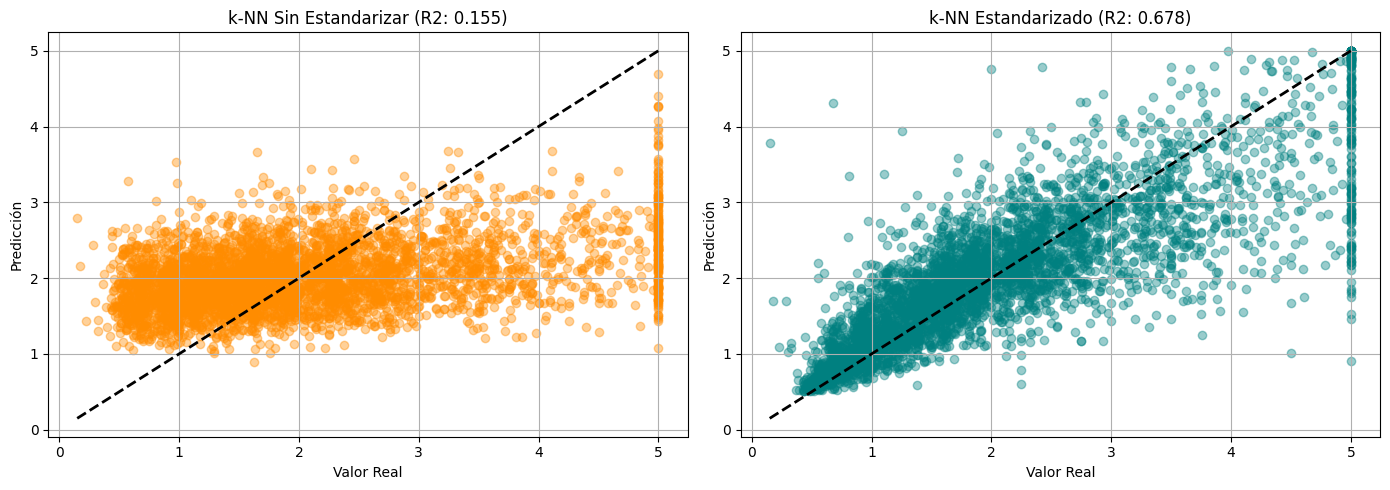

In [8]:
from sklearn.neighbors import KNeighborsRegressor

# 1. k-NN con datos estandarizados (k=10)
knn_stdr = KNeighborsRegressor(n_neighbors=10, metric='minkowski', p=2)
knn_stdr.fit(X_train_stdr, y_train)
y_pred_knn_stdr = knn_stdr.predict(X_test_stdr)

# 2. k-NN sin estandarizar (demostración del impacto de la escala)
knn_raw = KNeighborsRegressor(n_neighbors=10, metric='minkowski', p=2)
knn_raw.fit(X_train, y_train)
y_pred_knn_raw = knn_raw.predict(X_test)

r2_stdr = metrics.r2_score(y_test, y_pred_knn_stdr)
r2_raw = metrics.r2_score(y_test, y_pred_knn_raw)

print(f"R2 de k-NN (Estandarizado):    {r2_stdr:.4f}")
print(f"R2 de k-NN (Sin Estandarizar): {r2_raw:.4f}")

# Gráfica Comparativa k-NN
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, y_pred_knn_raw, alpha=0.4, color='darkorange')
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax[0].set_title(f"k-NN Sin Estandarizar (R2: {r2_raw:.3f})")
ax[0].set_xlabel("Valor Real")
ax[0].set_ylabel("Predicción")
ax[0].grid(True)

ax[1].scatter(y_test, y_pred_knn_stdr, alpha=0.4, color='teal')
ax[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax[1].set_title(f"k-NN Estandarizado (R2: {r2_stdr:.3f})")
ax[1].set_xlabel("Valor Real")
ax[1].set_ylabel("Predicción")
ax[1].grid(True)

plt.tight_layout()
plt.show()

---
## 4. Resumen y Matriz Comparativa de Modelos de Regresión

| Algoritmo | Parámetros Clave | Sensible a Escala | Ventaja Principal | Limitación Principal |
| :--- | :--- | :--- | :--- | :--- |
| **OLS** | Ninguno (analítico) | Moderada | Alta interpretabilidad y rapidez | Asume linealidad e independencia |
| **Lasso (L1)** | $\alpha$ (Regularización) | Alta | Selección automática de atributos | Puede descartar variables correlacionadas |
| **Ridge (L2)** | $\alpha$ (Regularización) | Alta | Mantiene atributos y reduce varianza | No produce modelos dispersos |
| **k-NN** | $k$, Métrica de Distancia | Muy Alta | No paramétrico, captura relaciones no lineales | Inferencia lenta en datasets grandes |

### Conclusiones
1. La **estandarización** es imprescindible en k-NN para evitar el sesgo por magnitudes de escala.
2. La **regularización** (Lasso/Ridge) estabiliza las predicciones cuando existe alta correlación entre atributos o riesgo de sobreajuste.